# Archelec — Topic Modeling of French Campaign Manifestos (1981–1993)

# Notebook 01 - Exploratory Data Analysis

## Context

The **Archelec** (Archives Électorales) corpus is a collection of campaign manifestos (*professions de foi*) from candidates in the French legislative elections of the Fifth Republic, digitised and transcribed by Sciences Po (CEVIPOF collection). This project is part of the *Deep Learning for NLP* course (ENSAE, 2026) and aims to apply topic modeling techniques to these political documents.

## Objective of this notebook

This notebook is the **first step of the project**: loading, cleaning and statistically exploring the data. It covers:

1. **Loading and joining** the CSV metadata (downloaded from [archelec.sciencespo.fr](https://archelec.sciencespo.fr/explorer)) with the OCR transcriptions (`.txt` files), using the common identifier `id`.

2. **OCR preprocessing**: removal of boilerplate text (Sciences Po headers, page footers), rejoining hyphenated words split across lines, whitespace normalisation. Then tokenisation and lemmatisation with spaCy (`fr_core_news_md`).

3. **Political mapping**: grouping the `titulaire-soutien` field into political families (Left, Right, Far-left, Far-right, Greens) using an exact-match dictionary combined with keyword-based rules.

4. **Exploratory analysis**: corpus descriptive statistics (volume per election year, document length distributions, breakdown by political family), global vocabulary (wordcloud, most frequent terms), and preliminary metadata × text cross-tabulations.

## Data

| Election | Year | Type | Documents |
|----------|------|------|-----------|
| Legislative | 1981 | Round 1 & 2 | ~3,100 |
| Legislative | 1988 | Round 1 & 2 | ~3,500 |
| Legislative | 1993 | Round 1 & 2 | ~5,800 |

**Available metadata**: date, department, constituency, candidate name/sex/age/profession, political affiliation (party), current mandate, etc.

## Notes

- OCR transcription quality is variable; preprocessing aims to reduce noise without losing thematic signal.
- Approximately 24% of documents have `titulaire-soutien` set to "non mentionné" and cannot be politically classified from metadata alone.
- This notebook produces the enriched DataFrame (`archelec_enriched.csv`) used by subsequent notebooks (topic modeling, cross-analyses...).

In [ ]:
# !pip install -r requirements.txt
seed = 42 
import os
import re
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Imports OK")

Imports OK


# 1 - Mapping parties to political families

We first map all the political parties to their families. It will be essential for the rest of our work so we tried to be exhaustive.

In [70]:
FAMILLE_POLITIQUE = {
 
    # ===========================================================
    # FAR LEFT
    # ===========================================================
    'Ligue communiste révolutionnaire': 'Far left',
    'Lutte ouvrière': 'Far left',
    'Parti des travailleurs': 'Far left',
    'Parti communiste internationaliste': 'Far left',
    'Parti socialiste unifié': 'Far left',  # PSU, left of PS
    'Parti ouvrier européen': 'Far left',
    'Mouvement pour un parti des travailleurs': 'Far left',
    'Parti communiste révolutionnaire': 'Far left',
    'Union communiste': 'Far left',
    'Alliance populaire': 'Far left',  
    'Parti communiste marxiste-léniniste de France': 'Far left',
    'Parti pour l\'organisation communiste': 'Far left',
    'Front autogestionnaire': 'Far left',
    'Parti communiste international': 'Far left',
 
    # ===========================================================
    # LEFT
    # ===========================================================

    # --- Communist Party ---
    'Parti communiste français': 'Left',
    'Parti communiste': 'Left',
 
    # --- Socialist Party and affiliates ---
    'Parti socialiste': 'Left',
    'Socialiste': 'Left',
    'socialiste': 'Left',
    'socialistes': 'Left',
    'Parti socialiste français': 'Left',
    'Mouvement des radicaux de gauche': 'Left',
    'Parti radical de gauche': 'Left',
    'Radicaux de gauche': 'Left',
    'Mouvement des citoyens': 'Left',   # Chevènement, sovereignist left
    'Mouvement des démocrates': 'Left',  # socialist current
    'Convention des institutions républicaines': 'Left',
 
    # --- Misc. left ---
    'Solidarité écologie gauche alternative': 'Left',
    'Alliance pour l\'écologie et la démocratie': 'Left',  # left-green
    'Union de la gauche': 'Left',
    'Majorité présidentielle': 'Left',  # 1981 and 1988 = Mitterrand
    'Alliance des Français pour le progrès': 'Left',  # PS 1993
 
    # ===========================================================
    # GREENS
    # ===========================================================
    'Les Verts': 'Greens',
    'Verts': 'Greens',
    'Génération écologie': 'Greens',
    'Europe écologie les Verts': 'Greens',
    'Entente des écologistes': 'Greens',
    'Mouvement écologiste indépendant': 'Greens',
    'Confédération écologiste': 'Greens',
    'Alliance écologiste indépendante': 'Greens',
 
    # --- Animal rights / misc. green ---
    'Nouveaux écologistes du rassemblement nature et animaux': 'Greens',
    'Nouveaux écologistes du rassemblement nature et animaux;Union nationale écologiste;Parti pour la défense des animaux;Mouvement universaliste': 'Greens',
    'Union nationale écologiste': 'Greens',
    'Parti pour la défense des animaux': 'Greens',
    'Mouvement universaliste': 'Greens',
 
    # ===========================================================
    # RIGHT (Centre + Moderate right + Gaullists)
    # ===========================================================
    # --- Gaullists ---
    'Rassemblement pour la République': 'Right',
    'Union pour la nouvelle République': 'Right',
    'Union des démocrates pour la République': 'Right',
    'gaulliste': 'Right',
 
    # --- UDF and components ---
    'Union pour la démocratie française': 'Right',
    'Centre des démocrates sociaux': 'Right',
    'Parti républicain': 'Right',
    'Parti radical': 'Right',  # Parti radical valoisien (right)
    'Parti radical valoisien': 'Right',
 
    # --- CNI and right-wing independents ---
    'Centre national des indépendants et paysans': 'Right',
    'Centre national des indépendants': 'Right',
    'Centre national des indépendants;Démocratie chrétienne française': 'Right',
    'Démocratie chrétienne française': 'Right',
    'Mouvement des réformateurs': 'Right',  # Giscardian centrists
 
    # --- Misc. right ---
    'Union des indépendants': 'Right',
    'divers droite': 'Right',
    'Rassemblement pour la France': 'Right',
 
    # ===========================================================
    # FAR RIGHT
    # ===========================================================
    'Front national': 'Far right',
    'Rassemblement national': 'Far right',
    'Parti des forces nouvelles': 'Far right',
    'Mouvement national républicain': 'Far right',

}


def get_famille(soutien):
    """Map titulaire-soutien to a political family.
    If multi-party (separated by ;), takes the first recognised one.
    """
    if pd.isna(soutien) or soutien == 'non mentionné':
        return 'Other / Unknown'
    for parti in soutien.split(';'):
        parti = parti.strip()
        if parti in FAMILLE_POLITIQUE:
            return FAMILLE_POLITIQUE[parti]
    return 'Other / Unknown'


# 2 - Data Loading and processing

## 2.1 - Data loading

In [71]:
# ============================================================
# Load the full CSV
# ============================================================
CSV_PATH = "data/archelect_search.csv"   
meta = pd.read_csv(CSV_PATH)
print(f"CSV loaded: {len(meta)} rows, {len(meta.columns)} columns")
print(f"\nColumns: {list(meta.columns)}")
meta.head(3)

CSV loaded: 33031 rows, 42 columns

Columns: ['id', 'date', 'subject', 'title', 'contexte-election', 'contexte-tour', 'cote', 'departement', 'departement-nom', 'departement-insee', 'identifiant de circonscription', 'images', 'pdf', 'ocr_url', 'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age', 'titulaire-age-calcule', 'titulaire-age-tranche', 'titulaire-profession', 'titulaire-mandat-en-cours', 'titulaire-mandat-passe', 'titulaire-associations', 'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste', 'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom', 'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule', 'suppleant-age-tranche', 'suppleant-profession', 'suppleant-mandat-en-cours', 'suppleant-mandat-passe', 'suppleant-associations', 'suppleant-autres-statuts', 'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations']


/var/folders/md/_fklkl9s1z9gj6bpnwj204y40000gn/T/ipykernel_28041/1984878617.py:5: DtypeWarning: Columns (8,9,10,12,28,29,30,31,32,33,34,35,36,37,38,39,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  meta = pd.read_csv(CSV_PATH)


,id,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,...,suppleant-age-calcule,suppleant-age-tranche,suppleant-profession,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations
0,EL009_L_1958_11_001_01_1_PF_01,1958-11-23,France;Élections législatives;Assemblée Nation...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,non mentionné,non mentionné,cultivateur,maire;conseiller général,non mentionné,non mentionné,non mentionné,Parti radical,non mentionné,non
1,EL009_L_1958_11_001_01_1_PF_02,1958-11-23,France;Ve République;Élections législatives;As...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,non mentionné,non mentionné,cultivateur,conseiller municipal,non mentionné,non mentionné,prisonnier de guerre,Union pour la nouvelle République,non mentionné,non
2,EL009_L_1958_11_001_01_1_PF_03,1958-11-23,Élections législatives;France;Assemblée Nation...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,non mentionné,non mentionné,cultivateur,non mentionné,non mentionné,non mentionné,non mentionné,Parti communiste français,non mentionné,non


We decide to restrain our analysis to the three following years : 1981, 1988 and 1993.
Indeed, these are the three years were both the metadata from the CSV () and the textual data are available, allowing us to merge the two information and enriching our analysis.

In [72]:
# Filtering years
meta['annee'] = pd.to_datetime(meta['date']).dt.year
ELECTIONS = [1981, 1988, 1993]
meta_filtered = meta[meta['annee'].isin(ELECTIONS)].copy()
print(f"Documents for {ELECTIONS}: {len(meta_filtered)}")
print(f"\nDistribution by year:")
print(meta_filtered['annee'].value_counts().sort_index())


# ============================================================
# Load text files
# ============================================================

TEXT_DIRS = {
    1981: "data/leg_81/",
    1988: "data/leg_88/",
    1993: "data/leg_93/",
}
texts = {}  

for year, directory in TEXT_DIRS.items():
    if not os.path.isdir(directory):
        print(f"⚠️  Directory not found: {directory}")
        continue
    for fpath in glob.glob(os.path.join(directory, "*.txt")):
        doc_id = os.path.splitext(os.path.basename(fpath))[0]
        with open(fpath, 'r', encoding='utf-8', errors='replace') as f:
            texts[doc_id] = f.read()

print(f"Text files loaded: {len(texts)}")

# Preview an ID for sanity check
if texts:
    sample_ids = list(texts.keys())[:1]
    for sid in sample_ids:
        print(f"  {sid}: {len(texts[sid])} chars, {len(texts[sid].split())} words")


# ============================================================
# Join text <-> metadata via ID
# ============================================================
df = meta_filtered[meta_filtered['id'].isin(texts.keys())].copy()
df['text_raw'] = df['id'].map(texts)

print(f"Documents with both text AND metadata: {len(df)}")
print(f"Text files without CSV match:          {len(texts) - len(df)}")
print(f"CSV entries without text:              {len(meta_filtered) - len(df)}")

Documents for [1981, 1988, 1993]: 12521

Distribution by year:
annee
1981    3133
1988    3551
1993    5837
Name: count, dtype: int64
Text files loaded: 12746
  EL136_L_1981_06_075_12_1_PF_03: 7700 chars, 1260 words
Documents with both text AND metadata: 12497
Text files without CSV match:          249
CSV entries without text:              24


We check if the merge was successful, and indeed it was as about only 250 out of the 12500 documents don't have both text and metadata. 

## 2.2 - Data processing

Despite the data being quite clean in the NLP context, we need to perform a slight processing to get rid of the OCR data. Indeed, **OCR** (Optical Character Recognition) is the process used to convert scanned document images into machine-readable text. The Archelec transcriptions were produced by OCR and contain typical artifacts: hyphenated words split across lines (`indus- triels` → `industriels`), repeated headers (`Sciences Po / fonds CEVIPOF`), page footers, and isolated page numbers. We clean these systematically before any NLP analysis to avoid injecting noise into the topic models.

In [73]:
# ============================================================
# OCR Preprocessing
# ============================================================
def clean_ocr(text):
    """Clean raw OCR text."""
  
    text = re.sub(r'Sciences Po\s*/\s*fonds CEVIPOF', '', text)
    text = re.sub(r'Vu,? le candidat.*$', '', text, flags=re.MULTILINE)
    text = re.sub(r'Ce document n.est pas un bulletin de vote.*$', '', text, flags=re.MULTILINE)

    text = re.sub(r'ELECTIONS?\s+LEGISLATIVES?.*?\n', '', text, flags=re.IGNORECASE)
    
    text = re.sub(r'(\w+)-\s*\n\s*(\w+)', r'\1\2', text)  # hyphen + newline
    text = re.sub(r'(\w+)- (\w+)', r'\1\2', text)          # hyphen + space
    
    text = re.sub(r'^\s*\d{1,2}\s*$', '', text, flags=re.MULTILINE)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply cleaning
if len(df) > 0:
    df['text_clean'] = df['text_raw'].apply(clean_ocr)
    
    df['n_words_raw'] = df['text_raw'].apply(lambda x: len(x.split()))
    df['n_words_clean'] = df['text_clean'].apply(lambda x: len(x.split()))
    
    print("Words per document (before cleaning):")
    print(df['n_words_raw'].describe().round(0))
    print("\nWords per document (after cleaning):")
    print(df['n_words_clean'].describe().round(0))
else:
    print("⚠️  No joined data — check paths above")


Words per document (before cleaning):
count    12497.0
mean       635.0
std        318.0
min         27.0
25%        403.0
50%        563.0
75%        836.0
max       3232.0
Name: n_words_raw, dtype: float64

Words per document (after cleaning):
count    12497.0
mean       617.0
std        314.0
min         18.0
25%        388.0
50%        547.0
75%        816.0
max       3155.0
Name: n_words_clean, dtype: float64


Processing successful.

We notice that some of the texts are written in German. As a result, for interpretability, we need to get rid of them.

In [74]:
# !pip install langdetect
from langdetect import detect, LangDetectException

def keep_only_french(text):
    """Détecte si le texte est majoritairement en français."""
    try:
        # On teste sur les 500 premiers caractères pour aller plus vite
        return detect(text[:500]) == 'fr' 
    except LangDetectException:
        return False # Si l'OCR est tellement mauvais qu'il ne trouve pas de langue

print(f"Taille du corpus avant filtrage : {len(df)}")

# On crée un masque et on filtre le DataFrame
df['is_french'] = df['text_clean'].apply(keep_only_french)
df = df[df['is_french'] == True].copy()
df = df.drop(columns=['is_french'])

print(f"Taille du corpus après filtrage (uniquement FR) : {len(df)}")

Taille du corpus avant filtrage : 12497
Taille du corpus après filtrage (uniquement FR) : 12385


Now it's time to map the political families we defined in part 1.

In [75]:
if len(df) > 0:
    df['famille'] = df['titulaire-soutien'].apply(get_famille)
    
    print("Distribution by political family:")
    print(df['famille'].value_counts())
    
    # ⚠️ If too many 'Other / Unknown', the dictionary needs extending
    pct_other = (df['famille'] == 'Other / Unknown').mean() * 100
    print(f"\n{'⚠️' if pct_other > 30 else '✅'} {pct_other:.0f}% unclassified")
    
    if pct_other > 30:
        print("\nUnrecognised parties (top 30):")
        others = df[df['famille'] == 'Other / Unknown']['titulaire-soutien']
        for val, count in others.value_counts().items():
            print(f"  {count:3d}× {val}")
        print("\n→ Add these parties to FAMILLE_POLITIQUE above")


Distribution by political family:
famille
Other / Unknown    3839
Left               3105
Right              2303
Far right          1255
Greens              961
Far left            922
Name: count, dtype: int64

⚠️ 31% unclassified

Unrecognised parties (top 30):
  3020× non mentionné
   95× Parti de la loi naturelle
   87× indépendant
   26× sans étiquette
   22× Parti du ras le bol
   21× libre
   17× aucun parti politique
   16× Chasse pêche nature traditions
   14× communiste
   13× Comités Juquin
   13× Union démocratique bretonne
   11× indépendants
   10× Comités d'initiative pour une nouvelle politique à gauche
   10× centriste
    9× Nouvelle solidarité
    9× sans parti politique
    9× Ecologie et survie mouvement d'écologie politique alsacien
    8× Comités communistes pour l'autogestion
    8× Parti communiste réunionnais
    8× non inscrit
    8× écologiste
    7× Ecologie les Verts
    7× gauche
    7× écologistes
    7× Centre gauche
    6× Socialistes
    5× Union pou

We have 30% of papers that are unclassified. Unfortunately, most of this unclassified papers come from the fact that the paper doesn't explicitly mentions its party. One could think about a 'party detection' according to what's said in the paper, but that is almost a project of its own. 

As 70% of the papers still represent a convenient amount for our analysis, we decide to move forward for the moment.

In [76]:
df = df[df['famille'] != 'Other / Unknown'].copy()
print(f"\nDocuments after filtering 'Other / Unknown': {len(df)}")


Documents after filtering 'Other / Unknown': 8546


## 2.3 - Tokenisation and Lemmatisation

Before any topic model can be applied, raw text must be reduced to a normalised vocabulary. We use **spaCy** (as in the lecture, `fr_core_news_md`) to lemmatise each word to its root form (e.g. *réduire*, *réductions*, *réduit* → `réduire`), filter out stopwords, and remove short tokens (< 3 characters). We also exclude corpus-specific filler words (*france*, *candidat*, *élection*, *vote*…) that appear in virtually every manifesto and would dominate topics without carrying discriminative information.

In [ ]:
# ============================================================
# Tokenisation + Lemmatisation with spaCy
# ============================================================
import spacy

nlp = spacy.load("fr_core_news_md", disable=["ner", "parser"])

# French stopwords + corpus-specific filler words
CUSTOM_STOPWORDS = {
    'être', 'avoir', 'faire', 'plus', 'tout', 'aussi', 'très', 'bien',
    'encore', 'déjà', 'toujours', 'tant', 'rien', 'autre', 'même',
    'non', 'oui', 'où', 'comme', 'sans', 'avec', 'dans', 'pour',
    'par', 'sur', 'entre', 'vers', 'sous', 'depuis', 'après', 'avant',
    'contre', 'chez', 'car', 'donc', 'cela', 'celui', 'cette', 'ceux', 
    'politique', "didier", 'yvon', 'serge', 'claire', 'france', 'français', 'udf', 'rpr', 'maire', 'dimanche',
    'candidat', 'élection', 'vote', 'voter', 'circonscription', 'gauche', 'droite', 'centre', 'communiste', 'socialiste', 'écologiste',
    'falloir', 'pouvoir', 'devoir', 'savoir', 'vouloir', 'venir', 'aller', 'voir', 'prendre',
    'député', 'janvier', 'février', 'mars', 'avril', 'mai', 'juin', 'juillet', 'août', 'septembre', 'octobre', 'novembre', 'décembre',
    'haben', 'ist', 'ich', 'auf', 'wir', 'sich', 'wird'
}

# !pip install nltk
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

german_stopwords = set(stopwords.words('german'))
french_stopwords = set(stopwords.words('french'))

CUSTOM_STOPWORDS.update(german_stopwords)
CUSTOM_STOPWORDS.update(french_stopwords)

def tokenize_and_lemmatize(text, min_len=3):
    """Tokenise, lemmatise, filter stopwords and short words."""
    doc = nlp(text)
    tokens = []
    for token in doc:
        if (token.is_alpha 
            and not token.is_stop 
            and len(token.lemma_) >= min_len
            and token.lemma_.lower() not in CUSTOM_STOPWORDS):
            tokens.append(token.lemma_.lower())
    return tokens


sample_text = "Il faut réduire considérablement les dépenses militaires et imposer une réforme fiscale radicale."
print(f"Input:  {sample_text}")
print(f"Output: {tokenize_and_lemmatize(sample_text)}")


# Apply to the full corpus (may take a few minutes)
if len(df) > 0:
    from tqdm import tqdm
    tqdm.pandas(desc="Tokenisation")
    df['tokens'] = df['text_clean'].progress_apply(tokenize_and_lemmatize)
    df['n_tokens'] = df['tokens'].apply(len)
    
    print(f"\nTokens per document:")
    print(df['n_tokens'].describe().round(0))
    
    # Remove documents that are too short (likely OCR noise)
    MIN_TOKENS = 20
    n_before = len(df)
    df = df[df['n_tokens'] >= MIN_TOKENS].copy()
    print(f"\nDocuments removed (< {MIN_TOKENS} tokens): {n_before - len(df)}")
    print(f"Documents remaining: {len(df)}")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/antoine/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Input:  Il faut réduire considérablement les dépenses militaires et imposer une réforme fiscale radicale.
Output: ['réduire', 'considérablement', 'dépense', 'militaire', 'imposer', 'réforme', 'fiscal', 'radical']


Tokenisation: 100%|██████████| 8546/8546 [07:34<00:00, 18.80it/s]



Tokens per document:
count    8546.0
mean      257.0
std       122.0
min        17.0
25%       170.0
50%       235.0
75%       338.0
max      1327.0
Name: n_tokens, dtype: float64

Documents removed (< 20 tokens): 1
Documents remaining: 8545


# 3 - Descriptive Statistics

Now, let's compute some descriptives statistics to get some insights that could give us ideas about our topic modeling coming next, and overall a better understanding of the data.

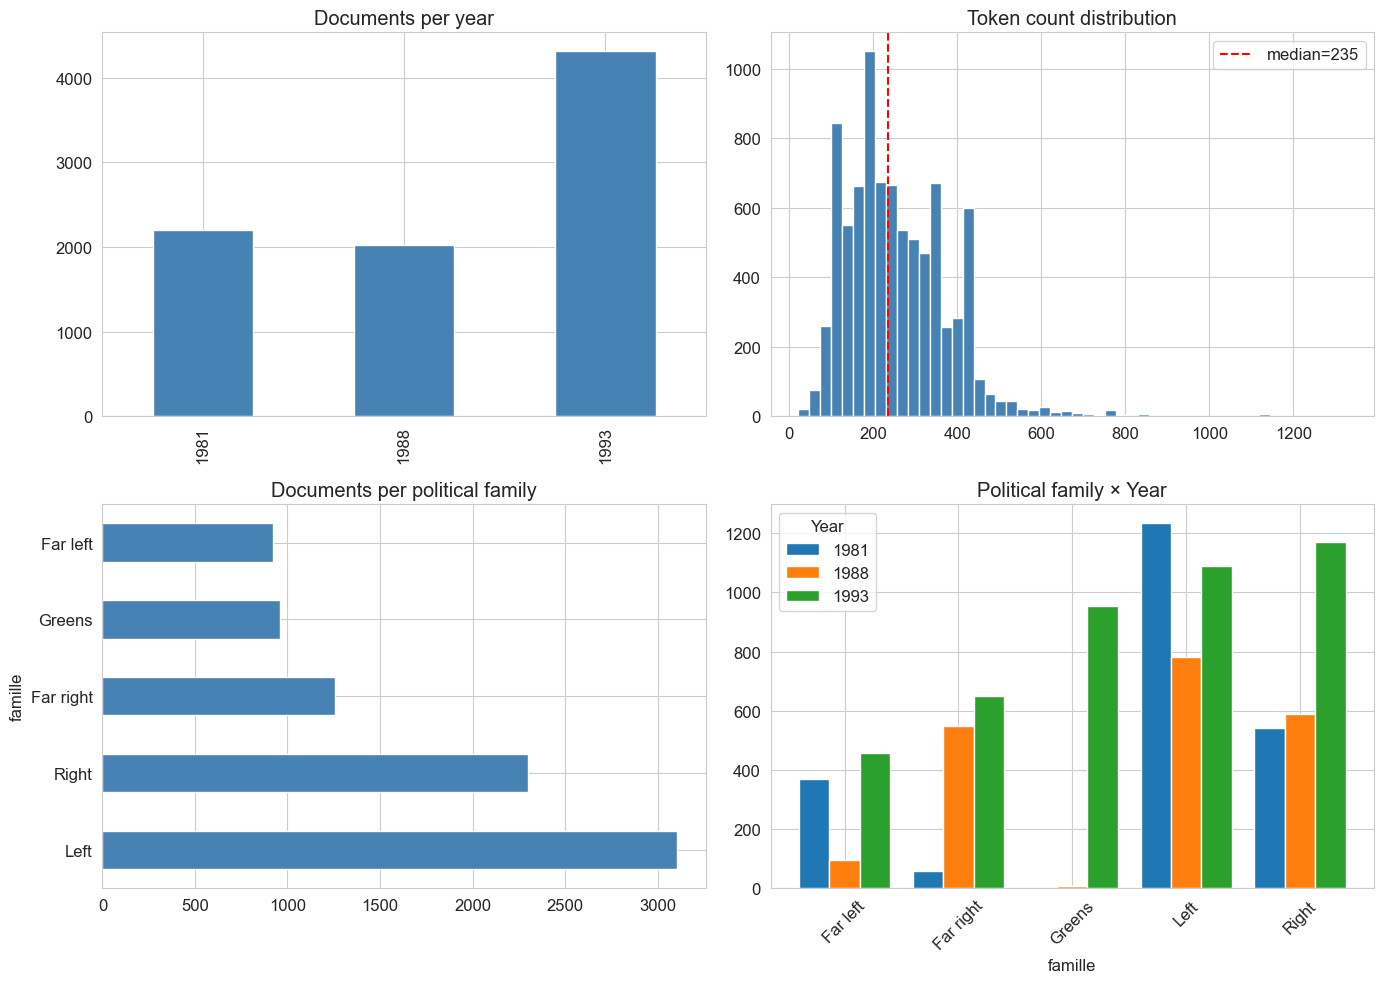

Figure saved: plots/eda_overview.png


In [78]:
if len(df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # a) Number of documents per year
    df['annee'].value_counts().sort_index().plot(kind='bar', ax=axes[0,0], color='steelblue')
    axes[0,0].set_title('Documents per year')
    axes[0,0].set_xlabel('')
    
    # b) Token count distribution
    df['n_tokens'].hist(bins=50, ax=axes[0,1], color='steelblue', edgecolor='white')
    axes[0,1].set_title('Token count distribution')
    axes[0,1].axvline(df['n_tokens'].median(), color='red', ls='--', label=f"median={df['n_tokens'].median():.0f}")
    axes[0,1].legend()
    
    # c) Documents per political family
    df['famille'].value_counts().plot(kind='barh', ax=axes[1,0], color='steelblue')
    axes[1,0].set_title('Documents per political family')
    
    # d) Family × Year
    ct = pd.crosstab(df['famille'], df['annee'])
    ct.plot(kind='bar', ax=axes[1,1], width=0.8)
    axes[1,1].set_title('Political family × Year')
    axes[1,1].legend(title='Year')
    axes[1,1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig('plots/eda_overview.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure saved: plots/eda_overview.png")

Some remarks :
- Notably more documents in 1993
- Normally distributed in length, but the articles are not really long
- Mainstream families 'Left' and 'Right' have (coherent) the most documents
- We see that the climate concern rose between 1988 and 1993, reaching almost Left and Right nummbers, marking a raise of awareness on climate change in these years. Already a cool finding.

Total vocabulary: 53637 unique terms
Top 30:
  19674  national
  13782  social
  13344  emploi
  11870  parti
  11029  nouveau
  10872  majorité
  10167  force
   9556  homme
   9378  pays
   8608  chômage
   8232  vie
   8075  travail
   7984  entreprise
   7911  union
   7850  conseiller
   7756  travailleur
   7630  grand
   7408  législatif
   7277  monsieur
   7259  donner
   7061  gouvernement
   6978  mitterrand
   6886  avenir
   6758  suppléant
   6631  défendre
   6507  assemblée
   6196  changement
   6063  droit
   6034  enfant
   6022  voix


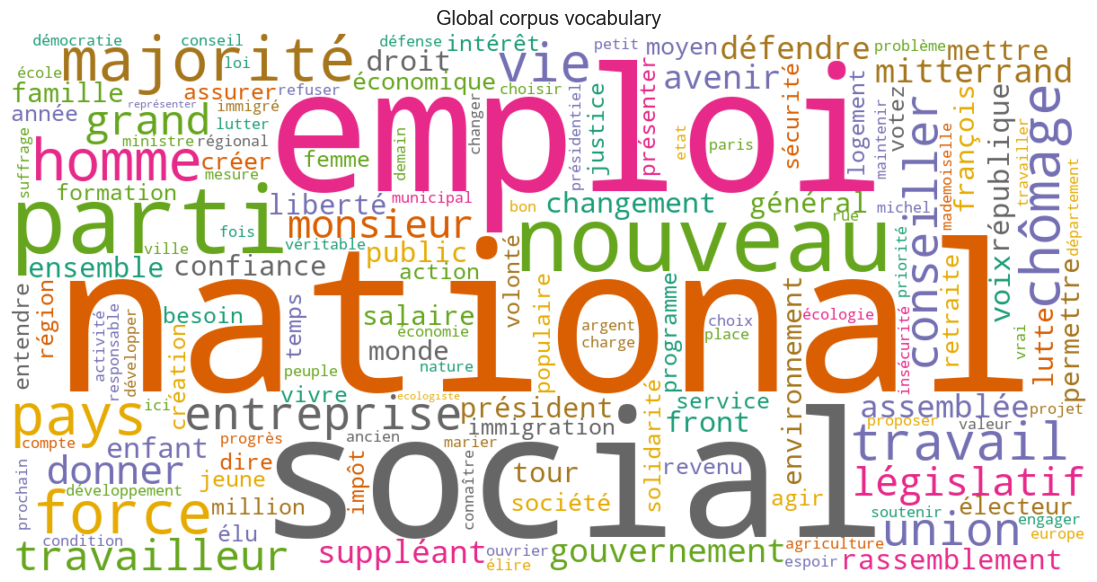

In [79]:
# most frequent words
if len(df) > 0:
    from wordcloud import WordCloud
    
    all_tokens = [t for tokens in df['tokens'] for t in tokens]
    freq = Counter(all_tokens)
    
    print(f"Total vocabulary: {len(freq)} unique terms")
    print(f"Top 30:")
    for word, count in freq.most_common(30):
        print(f"  {count:5d}  {word}")
    
    wc = WordCloud(width=1200, height=600, background_color='white',
                   max_words=150, colormap='Dark2')
    wc.generate_from_frequencies(freq)
    
    plt.figure(figsize=(14, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Global corpus vocabulary')
    plt.savefig('plots/wordcloud_global.png', dpi=150, bbox_inches='tight')
    plt.show()

Save for main notebook

In [80]:
df.to_csv('data/archelec_eda.csv', index=False)